In [1]:
import pandas as pd
import numpy as np
import os
import math
from pathlib import Path
from matplotlib import pyplot as plt
idx = pd.IndexSlice
import xarray as xr
from read_mym import read_mym_df

from constants_BUMA import(
    SCENARIO_SELECT, FILE_ADDITION,
    REGIONS, REGIONS_RANGE,
    START_YEAR, END_YEAR, HIST_YEAR, YEARS, YEAR_LIST_SVA,
    INFLATION, 
    FLAG_ALPHA, FLAG_EXPDEC, FLAG_NORMAL,
    LOWCOMM,
    GOMPERTZ_EXPDEC,
    MINIMUM_COM
)


In [2]:
base_directory = Path("..", "IMAGE-Mat_old_version", "IMAGE-Mat", "BUMA")
database_directory = base_directory / "files_DB" / SCENARIO_SELECT
image_directory = base_directory / "files_IMAGE" / SCENARIO_SELECT
assert database_directory.is_dir(), database_directory
assert image_directory.is_dir()


In [3]:
#%% # Reading all csv files for buildings that are external to IMAGE

# 1) scenario independent data
# Avg_m2_cap; unit: m2/capita; meaning: average square meters per person (by region & rural/urban) 
average_m2_capita: pd.DataFrame = pd.read_csv(base_directory.joinpath('files_DB','Average_m2_per_cap.csv'), index_col = [0,1]) 

# 1) scenario dependent data 
# Housing_type; unit: %; meaning: the share of the PEOPLE living in a particular building type (by region & by area) 
housing_type_data: pd.DataFrame = pd.read_csv(database_directory.joinpath('Housing_type_dynamic.csv'), index_col = [0,1,2]) 
# Building_materials; unit: kg/m2; meaning: the average material use per square meter (by building type, by region & by area)
building_materials: pd.DataFrame = pd.read_csv(database_directory.joinpath('Building_materials' + FILE_ADDITION + '.csv'), index_col = [0,1,2]) 
# 7 building materials in 4 commercial building types; unit: kg/m2; meaning: the average material use per square meter (by commercial building type)
materials_commercial: pd.DataFrame = pd.read_csv(database_directory.joinpath('materials_commercial' + FILE_ADDITION + '.csv'), index_col = [0,1])  

# load IMAGE data-files (MyM file format)
floorspace: pd.DataFrame = read_mym_df(image_directory.joinpath("res_Floorspace.out"))
floorspace = floorspace[['time','DIM_1',2,3]].rename(columns={"DIM_1": "Region", 'time':'t', 2:'Urban', 3:'Rural'})
# the other columns are average per capita floorspace per quintile (we also exclude the average per capita floorspace of the total population in column 1, 
# because we use the urban & rural specific totals)
floorspace = floorspace[floorspace.Region != REGIONS + 1] #removing region 27
floorspace = floorspace[floorspace['t'].isin(list(range(START_YEAR, END_YEAR+1)))]
# remove all data beyond 2060 to save runtime, we have not yet generated scenario results beyond 2060

# we use the inflation corrected SVA to adjust for the fact that IMAGE provides gdp/cap in 2005 US$
service_value_added_2005: pd.DataFrame = pd.read_csv(image_directory.joinpath('sva_pc.csv'), index_col = [0])
service_value_added = service_value_added_2005 * INFLATION
# added cubic interpolation to the sva_pc (presumed linear interpolation between 5-year original data caused sawtooth demand/inflow throughout the scenario projection after 2025)
service_value_added = service_value_added.loc[YEAR_LIST_SVA,:].reindex(list(range(1970, END_YEAR + 1,1))).interpolate(method='cubic') 

# Load fitted regression parameters
if FLAG_ALPHA == 0:
    gompertz = pd.read_csv(base_directory / 'files_commercial/Gompertz_parameters.csv', index_col = [0])
else:
    gompertz = pd.read_csv(base_directory / 'files_commercial/Gompertz_parameters_alpha.csv', index_col = [0])

lifetimes_commercial = pd.read_csv(base_directory / 'files_lifetimes' / SCENARIO_SELECT / 'lifetimes_comm.csv', index_col = [0,1])  # Weibull parameter database for commercial buildings (shape & scale parameters given by region, area & building-type)
# TODO originally lifetimes_commercial was only read in with FLAG_NORMAL == 0 

if FLAG_NORMAL == 0:
    lifetimes_residential   = pd.read_csv(base_directory / 'files_lifetimes' / SCENARIO_SELECT / 'lifetimes.csv', index_col = [0,1,2,3])   # Weibull parameter database for residential buildings (shape & scale parameters given by region, area & building-type)
else:
    lifetimes_residential = pd.read_csv(base_directory / 'files_lifetimes' / 'lifetimes_normal.csv')  # Normal distribution database (Mean & StDev parameters given by region, area & building-type, though only defined by region for now)



In [4]:
test = pd.read_csv(database_directory.joinpath('Housing_type_dynamic.csv'), index_col = [0,1,2]) 

In [5]:
gompertz["Govt+"]

a    9.9800
b    2.6520
c    0.0517
Name: Govt+, dtype: float64

In [6]:
# interpolate lifetime data

lifetimes_commercial_interpolated = (
    lifetimes_commercial.unstack(level='Region')
    .reindex(YEARS)
    .interpolate(method='linear', limit=300, limit_direction='both')
    .stack(level='Region')
)
# Interpolate for the 'Shape' column for residential data
lifetimes_res_shape_interpolated = (
    lifetimes_residential['Shape']
    .unstack(level='time')  # Temporarily unstack 'time' level
    .reindex(columns=YEARS)  # Reindex to include all years in the specified range
    .interpolate(method='linear', limit=300, limit_direction='both', axis=1)  # Interpolate missing years
    .stack(level='time')  # Stack 'time' level back to its original position
)

# Interpolate for the 'Scale' column for residential data
lifetimes_res_scale_interpolated = (
    lifetimes_residential['Scale']
    .unstack(level='time')
    .reindex(columns=YEARS)
    .interpolate(method='linear', limit=300, limit_direction='both', axis=1)
    .stack(level='time')
)

# Combine both interpolated 'Shape' and 'Scale' columns back into a single DataFrame
lifetimes_residential_interpolated = pd.concat(
    [lifetimes_res_shape_interpolated, lifetimes_res_scale_interpolated],
    axis=1,
    keys=['Shape', 'Scale']
)

/tmp/ipykernel_276014/3733855429.py:4: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  lifetimes_commercial.unstack(level='Region')


In [7]:
# also interpolate housing type data
index_ht = pd.MultiIndex.from_product([list(range(HIST_YEAR, END_YEAR + 1)), 
                                       list(range(1,REGIONS + 1)), 
                                       ['Urban', 'Rural'] ]) 
housing_type = pd.DataFrame(np.nan, index=index_ht, columns=housing_type_data.columns)
housing_type.index.names = ['Year','Region','Area']

for year in list(housing_type_data.index.levels[0]):
    housing_type.loc[idx[year,:,:],:] = housing_type_data.loc[idx[year,:,:],:]
    
for region in list(range(1,REGIONS + 1)):
    for area in ['Urban', 'Rural']:
        housing_types_interpolated = housing_type.loc[idx[:,region,area],:].interpolate(method='linear', limit_direction='both')
        housing_type.loc[idx[:,region,area],:] = housing_types_interpolated.values   

#TODO this interpolation leads to some vrows not being very close to 1 anymore                                                       
       

In [8]:
# Select gompertz curve paramaters for the total commercial m2 demand (stock)
alpha, beta, gamma = (
    (gompertz['All']['a'], gompertz['All']['b'], gompertz['All']['c'])
    if FLAG_EXPDEC == 0 else GOMPERTZ_EXPDEC          
)
alpha_low = alpha * LOWCOMM                                    # alpha multiplied with a factor, lowering the maximum per capita commecrial floorspace between (2020 and 2050) 

# find the total commercial m2 stock (in Millions of m2)
commercial_m2_cap = pd.DataFrame(index=YEARS, columns=REGIONS_RANGE)
commercial_m2_cap_low = commercial_m2_cap.copy()

# Compute commercial floorspace using Gompertz curves
for year in YEARS:
    for region in REGIONS_RANGE:
        exp_factor = math.exp((-gamma/1000) * service_value_added[str(region)][year])
        if FLAG_EXPDEC == 0:
            commercial_m2_cap[region][year] = alpha * math.exp(-beta * exp_factor)
            commercial_m2_cap_low[region][year] = alpha_low * math.exp(-beta * exp_factor)
        else:
            commercial_m2_cap[region][year] = max(0.542, alpha - beta * exp_factor)

# commercial floorspace is scaled here (in case lowComm is not 1)
scale_comm = pd.Series([1.0, 0.0], index=[2020, 2060], name='time').reindex(YEARS).interpolate(method='linear', limit=300, limit_direction='both')
commercial_m2_cap    = commercial_m2_cap.mul(scale_comm, axis=0) + commercial_m2_cap_low.mul((1-scale_comm), axis=0)


/tmp/ipykernel_276014/2903140353.py:17: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  commercial_m2_cap[region][year] = alpha * math.exp(-beta * exp_factor)
/tmp/ipykernel_276014/2903140353.py:18: FutureWarning: ChainedAssignmentError: behav

In [9]:
# Subdivide the total commercial floorspace across Offices, Retail+, Govt+ & Hotels+
types = ["Office", "Retail+", "Hotels+", "Govt+"]
index = pd.MultiIndex.from_product([types, REGIONS_RANGE, YEARS], names=["Type", "Region", "Year"])
commercial_m2_cap_all = pd.DataFrame(index=index, columns=["m2_per_cap"]).fillna(0)

#TODO move to a util file
# Define a function to calculate Gompertz growth
def gompertz_value(category, region, year, sva_data):
    """Calculate the Gompertz value for a given category, region, and year."""
    params = gompertz[category]
    return params['a'] * math.exp(-params['b'] * math.exp((-params['c'] / 1000) * sva_data[str(region)][year]))

for year in YEARS:
    for region in REGIONS_RANGE:
        # Calculate floorspace for all types and update the minimum values
        floorspace_commercial_list = {}
        for type_ in types:
            #value = gompertz_value(type_, region, year, service_value_added)
            params = gompertz[type_]
            value = params['a'] * math.exp(-params['b'] * math.exp((-params['c'] / 1000) * service_value_added[str(region)][year]))
            floorspace_commercial_list[type_] = value
            MINIMUM_COM[type_] = min(MINIMUM_COM[type_], value)

        # Sum all floorspace values for normalization
        commercial_sum = sum(floorspace_commercial_list.values())

        # Calculate and assign the floorspace for each type
        for type_ in types:
            commercial_m2_cap_all.loc[(type_, region, year), "m2_per_cap"] = (
                commercial_m2_cap.loc[year, region] * (floorspace_commercial_list[type_] / commercial_sum)
            )


/tmp/ipykernel_276014/3519961243.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  commercial_m2_cap_all = pd.DataFrame(index=index, columns=["m2_per_cap"]).fillna(0)
/tmp/ipykernel_276014/3519961243.py:29: PerformanceWarning: indexing past lexsort depth may impact performance.
  commercial_m2_cap_all.loc[(type_, region, year), "m2_per_cap"] = (
/tmp/ipykernel_276014/3519961243.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.86773961804217' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  commercial_m2_cap_all.loc[(type_, region, year), "m2_per_cap"] = (
/tmp/ipykernel_276014/3519961243.py:29: PerformanceWarning: indexing past lexsort depth

In [10]:
from floorspace import get_image_floorspace
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    floorspace_image = get_image_floorspace(image_directory, base_directory)

In [11]:
# Reshaping and merging commercial and residential floorspace
floorspace = floorspace.rename({"t":"Year"}, axis = 1)
floorspace = floorspace.set_index(["Year", "Region"])
floorspace = floorspace.rename_axis("Type", axis = 1)
commercial_m2_cap_all = commercial_m2_cap_all.unstack("Type")
commercial_m2_cap_all = commercial_m2_cap_all.droplevel(0, axis = 1)
floorspace = floorspace.merge(commercial_m2_cap_all, how = "left", left_index=True, right_index=True)
floorspace_dataset = floorspace.to_xarray()

In [12]:
floorspace_array = xr.DataArray(0.0, dims=("Year", "Region", "type"), coords={
    "Year": floorspace_dataset.coords["Year"],
    "Region": floorspace_dataset.coords["Region"],
    "type": ["Urban", "Rural", "Office", "Retail+", "Hotels+", "Govt+"],
})

for data_name, data_var in floorspace_dataset.data_vars.items():
    floorspace_array.loc[:, :, data_name] = data_var

In [13]:
floorspace_array.sum()

<xarray.DataArray ()> Size: 8B
array(126730.79161416)

In [14]:
# For the RESIDENTIAL & COMMERCIAL floorspace: Derive the annual trend (in m2/cap) 
# over the initial 10 years of IMAGE data
# Get the growth by year (for the first 10 years)
interp_coor = floorspace_array.sel(Year=range(1971, 1981)).coords
trend_1971_1981 = xr.DataArray(
    floorspace_array.sel(Year=range(1971, 1981)).to_numpy()/floorspace_array.sel(Year=range(1972, 1982)).to_numpy(),
    dims=("Year", "Region", "type"),
    coords=interp_coor
)

In [15]:
# Average global annual decline in floorspace/cap in %, rural: 1%; urban 1.2%;  commercial: 1.26-2.18% /yr 
avg_trend_1971_1981 = trend_1971_1981.mean(["Year", "Region"])

In [16]:
# Find minumum or maximum values in the original IMAGE data 
# (Just for residential, commercial minimum values have been calculated above)
min_floorspace = floorspace_array.min(["Year", "Region"])

In [17]:
# define historic floorspace (1820-1970) in m2/cap
# Calculate the actual values used between 1820 & 1970, given the trends & the min/max values
start_year = 1820
end_year = 1970
delta_year = end_year - start_year
fraction_interpol = avg_trend_1971_1981.values.reshape(1, -1)**(delta_year - np.arange(end_year-start_year)).reshape(-1, 1)
reshaped_floor_1971 = floorspace_array.loc[1971, :, :].values.reshape(1, *floorspace_array.shape[1:])
interpol_floor_1820_1970_np = reshaped_floor_1971*fraction_interpol.reshape(fraction_interpol.shape[0], 1, -1)
where_too_low = np.where(interpol_floor_1820_1970_np < min_floorspace.values)
interpol_floor_1820_1970_np[where_too_low] = min_floorspace.values[where_too_low[-1]]
interpol_floor_1820_1970_xr = xr.DataArray(interpol_floor_1820_1970_np, dims=floorspace_array.dims,
                                           coords={
                                               "Year": np.arange(start_year, end_year),
                                               "Region": floorspace_array.coords["Region"],
                                               "type": floorspace_array.coords["type"]
                                           })

In [18]:
years_1820_1970 = xr.DataArray(np.arange(start_year, end_year), dims=["Year"], coords={"Year": np.arange(start_year, end_year)})
floor_1820_1970 = floorspace_image.loc[1971]*avg_trend_1971_1981**(end_year-years_1820_1970)
floor_1820_1970 = floor_1820_1970.where(floor_1820_1970 > min_floorspace, min_floorspace)

In [19]:
floor_1820_1970.sum(), interpol_floor_1820_1970_xr.sum()

(<xarray.DataArray ()> Size: 8B
 array(79247.865437),
 <xarray.DataArray ()> Size: 8B
 array(79247.865437))

In [20]:
# To avoid full model setup in 1820 (all required stock gets built in yr 1) 
# we assume another tail that linearly increases to the 1820 value over a 100 year 
# time period, so 1720 = 0
far_start_year = 1721
interpol_floor_1721_1820 = np.linspace(0, interpol_floor_1820_1970_np[0, :, :], num=(start_year - far_start_year), endpoint=False)
interpol_floor_1721_1820_xr = xr.DataArray(interpol_floor_1721_1820,
                                           dims=floorspace_array.dims,
                                           coords={
                                               "Year": np.arange(far_start_year, start_year),
                                               "Region": floorspace_array.coords["Region"],
                                               "type": floorspace_array.coords["type"]
                                           })

In [21]:
interp_coor = floorspace_image.sel(Year=range(1971, 1981)).coords
trend_1971_1981 = xr.DataArray(
    floorspace_image.sel(Year=range(1971, 1981)).to_numpy()/floorspace_image.sel(Year=range(1972, 1982)).to_numpy(),
    dims=("Year", "Region", "type"),
    coords=interp_coor
)

# Average global annual decline in floorspace/cap in %, rural: 1%; urban 1.2%;  commercial: 1.26-2.18% /yr 
avg_trend_1971_1981 = trend_1971_1981.mean(["Year", "Region"])

# Find minumum or maximum values in the original IMAGE data 
# (Just for residential, commercial minimum values have been calculated above)
min_floorspace = floorspace_image.min(["Year", "Region"])

# Compute the floorspace between 1820 and 1970 with extrapolation
years_1820_1970 = xr.DataArray(np.arange(start_year, end_year), dims=["Year"], coords={"Year": np.arange(start_year, end_year)})
floor_1820_1970 = floorspace_image.loc[1971]*avg_trend_1971_1981**(end_year-years_1820_1970)
floor_1820_1970 = floor_1820_1970.where(floor_1820_1970 > min_floorspace, min_floorspace).transpose()

years_1721_1820 = xr.DataArray(np.arange(far_start_year, start_year), dims=["Year"], coords={"Year": np.arange(far_start_year, start_year)})
floor_1721_1820 = floor_1820_1970[0]*(1-(start_year - years_1721_1820)/(start_year-far_start_year+1)).transpose()

floorspace = xr.concat((floor_1721_1820, floor_1820_1970, floorspace_image), dim="Year")


In [22]:
from floorspace import extrapolate_floorspace

floorspace = extrapolate_floorspace(floorspace_image)

In [23]:
# combine historic with IMAGE data here
floorspace_xr = xr.concat((interpol_floor_1721_1820_xr, interpol_floor_1820_1970_xr, floorspace_array), dim="Year")

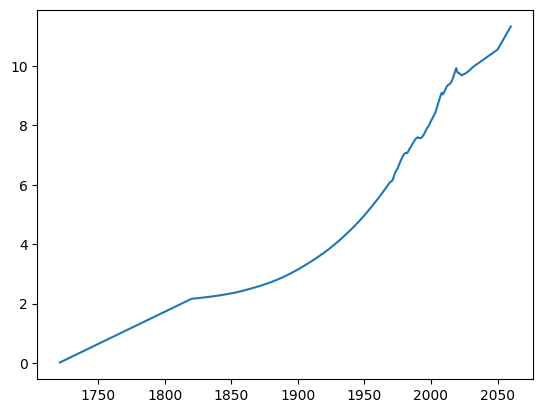

In [27]:
plt.plot(floorspace.coords["Year"], floorspace.mean(["Region", "type"]))
plt.show()

In [25]:
#%% SQUARE METER Calculations (requires dynamic stock model to disaggregate building types) ----
# Renaming columns for m2 data
column_mapping = {'1': 'Detached', '2': 'Semi-detached', '3': 'Appartment', '4': 'High-rise'}

average_m2_capita.rename(columns=column_mapping, inplace=True)

# define the relative importance of housing type wthin the stock of floorspace 
# (not just accounting for the changing share of people living accross housing types, 
# but also acknowledging that some housing types typically involve a higher floorspace per capita)
# the avg_m2 (per capita) only affects the relative allocation of total IMAGE floorsapce over building types
relative_m2_capita = average_m2_capita * housing_type
stock_share = relative_m2_capita.div(relative_m2_capita.sum(axis=1), axis=0)


In [26]:
stock_share_1971_onwards = stock_share.loc[pd.IndexSlice[:, :, 1971:]].reorder_levels(['Area', 'Year', 'Region']).sort_index()
stacked_floorspace = floorspace[["Urban", "Rural"]].stack().rename_axis(index={"Type": "Area"}).reorder_levels(['Area', 'Year', 'Region']).sort_index()

residential_m2 = stock_share_1971_onwards.apply(lambda x: x * stacked_floorspace.loc[x.index], axis=0)

IndexError: arrays used as indices must be of integer (or boolean) type

In [23]:
residential_m2

Detached  Semi-detached  Appartment  High-rise
Area  Year Region                                                 
Rural 1971 1       26.786387       2.417322    1.630821   1.163829
           2       32.074117       0.480236    0.539977   0.154139
           3       14.319766       1.292279    0.871823   0.622173
           4       14.527948       1.311066    0.884497   0.631218
           5       12.630755       1.139855    0.768992   0.548788
...                      ...            ...         ...        ...
Urban 2060 22       5.992551       3.844638    6.088305   5.600985
           23      21.291767       0.852217    9.571704  10.284312
           24       4.523314      10.341599    8.687678   6.447409
           25       5.166363       3.056052    4.839512   5.311453
           26       4.083409       2.415453    3.825072   4.198086

[4680 rows x 4 columns]

In [24]:
avg_m2_cap_rur_det = average_m2_capita[average_m2_capita.index.get_level_values('Area') == 'Rural'].droplevel('Area')["Detached"]
avg_m2_cap_rur_sem = average_m2_capita[average_m2_capita.index.get_level_values('Area') == 'Rural'].droplevel('Area')["Semi-detached"]
avg_m2_cap_rur_app = average_m2_capita[average_m2_capita.index.get_level_values('Area') == 'Rural'].droplevel('Area')["Appartment"]
avg_m2_cap_rur_hig = average_m2_capita[average_m2_capita.index.get_level_values('Area') == 'Rural'].droplevel('Area')["High-rise"]

In [25]:
housing_type_rur_det = housing_type[housing_type.index.get_level_values('Area') == 'Rural'].droplevel('Area')["Detached"].unstack()
housing_type_rur_sem = housing_type[housing_type.index.get_level_values('Area') == 'Rural'].droplevel('Area')["Semi-detached"].unstack()
housing_type_rur_app = housing_type[housing_type.index.get_level_values('Area') == 'Rural'].droplevel('Area')["Appartment"].unstack()
housing_type_rur_hig = housing_type[housing_type.index.get_level_values('Area') == 'Rural'].droplevel('Area')["High-rise"].unstack()

In [26]:
relative_rur_det = avg_m2_cap_rur_det * housing_type_rur_det
relative_rur_sem = avg_m2_cap_rur_sem * housing_type_rur_sem
relative_rur_app = avg_m2_cap_rur_app * housing_type_rur_app
relative_rur_hig = avg_m2_cap_rur_hig * housing_type_rur_hig
total_rur        = relative_rur_det + relative_rur_sem + relative_rur_app + relative_rur_hig

In [27]:
stock_share_rur_det = relative_rur_det / total_rur
stock_share_rur_sem = relative_rur_sem / total_rur
stock_share_rur_app = relative_rur_app / total_rur
stock_share_rur_hig = relative_rur_hig / total_rur

In [28]:
stock_share_rur_det

Region,1,2,3,4,5,6,7,8,9,10,...,17,18,19,20,21,22,23,24,25,26
Year,,,,,,,,,,,,,,,,,,,,,
1721,0.837118,0.96468,0.837118,0.837118,0.837118,0.837118,0.837118,0.837118,0.837118,0.837118,...,0.837118,0.836329,0.837118,0.841539,0.837118,0.837118,0.912221,0.920214,0.760062,0.837118
1722,0.837118,0.96468,0.837118,0.837118,0.837118,0.837118,0.837118,0.837118,0.837118,0.837118,...,0.837118,0.836329,0.837118,0.841539,0.837118,0.837118,0.912221,0.920214,0.760062,0.837118
1723,0.837118,0.96468,0.837118,0.837118,0.837118,0.837118,0.837118,0.837118,0.837118,0.837118,...,0.837118,0.836329,0.837118,0.841539,0.837118,0.837118,0.912221,0.920214,0.760062,0.837118
1724,0.837118,0.96468,0.837118,0.837118,0.837118,0.837118,0.837118,0.837118,0.837118,0.837118,...,0.837118,0.836329,0.837118,0.841539,0.837118,0.837118,0.912221,0.920214,0.760062,0.837118
1725,0.837118,0.96468,0.837118,0.837118,0.837118,0.837118,0.837118,0.837118,0.837118,0.837118,...,0.837118,0.836329,0.837118,0.841539,0.837118,0.837118,0.912221,0.920214,0.760062,0.837118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2056,0.837118,0.96468,0.837118,0.837118,0.837118,0.837118,0.837118,0.837118,0.837118,0.837118,...,0.837118,0.836329,0.837118,0.841539,0.837118,0.837118,0.912221,0.920214,0.760062,0.837118
2057,0.837118,0.96468,0.837118,0.837118,0.837118,0.837118,0.837118,0.837118,0.837118,0.837118,...,0.837118,0.836329,0.837118,0.841539,0.837118,0.837118,0.912221,0.920214,0.760062,0.837118
2058,0.837118,0.96468,0.837118,0.837118,0.837118,0.837118,0.837118,0.837118,0.837118,0.837118,...,0.837118,0.836329,0.837118,0.841539,0.837118,0.837118,0.912221,0.920214,0.760062,0.837118


In [29]:
avg_m2_cap_rur_det * housing_type_rur_det

Region,1,2,3,4,5,6,7,8,9,10,...,17,18,19,20,21,22,23,24,25,26
Year,,,,,,,,,,,,,,,,,,,,,
1721,26.866158,31.565226,26.866158,26.866158,26.866158,26.866158,26.866158,26.866158,26.866158,26.866158,...,26.866158,26.711474,26.866158,27.761697,26.866158,26.866158,29.180052,29.90625,16.559323,26.866158
1722,26.866158,31.565226,26.866158,26.866158,26.866158,26.866158,26.866158,26.866158,26.866158,26.866158,...,26.866158,26.711474,26.866158,27.761697,26.866158,26.866158,29.180052,29.90625,16.559323,26.866158
1723,26.866158,31.565226,26.866158,26.866158,26.866158,26.866158,26.866158,26.866158,26.866158,26.866158,...,26.866158,26.711474,26.866158,27.761697,26.866158,26.866158,29.180052,29.90625,16.559323,26.866158
1724,26.866158,31.565226,26.866158,26.866158,26.866158,26.866158,26.866158,26.866158,26.866158,26.866158,...,26.866158,26.711474,26.866158,27.761697,26.866158,26.866158,29.180052,29.90625,16.559323,26.866158
1725,26.866158,31.565226,26.866158,26.866158,26.866158,26.866158,26.866158,26.866158,26.866158,26.866158,...,26.866158,26.711474,26.866158,27.761697,26.866158,26.866158,29.180052,29.90625,16.559323,26.866158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2056,26.866158,31.565226,26.866158,26.866158,26.866158,26.866158,26.866158,26.866158,26.866158,26.866158,...,26.866158,26.711474,26.866158,27.761697,26.866158,26.866158,29.180052,29.90625,16.559323,26.866158
2057,26.866158,31.565226,26.866158,26.866158,26.866158,26.866158,26.866158,26.866158,26.866158,26.866158,...,26.866158,26.711474,26.866158,27.761697,26.866158,26.866158,29.180052,29.90625,16.559323,26.866158
2058,26.866158,31.565226,26.866158,26.866158,26.866158,26.866158,26.866158,26.866158,26.866158,26.866158,...,26.866158,26.711474,26.866158,27.761697,26.866158,26.866158,29.180052,29.90625,16.559323,26.866158
